In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
Color_1 = '#1f77b4'
Color_2 = '#e75a44'
Color_3 = '#52acab'
Color_endge = '#00008b'

# 1. Подготовка данных

__Описание колонок:__

- `survival` - Survival (0 = No, 1 = Yes)
- `pclass` - Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- `sex` - Sex
- `Age` - Age in years
- `sibsp` - Number of siblings / spouses aboard the Titanic
- `parch` - Number of parents / children aboard the Titanic
- `ticket` - Ticket number
- `fare` - Passenger fare
- `cabin` - Cabin number
- `embarked` - Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

In [3]:
train_data = pd.read_csv("train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_data = pd.read_csv("test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
test_data.info(), train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass  

(None, None)

`Cabin` состоит в основном из null, поэтому для анализа непреминимо.

In [6]:
train_data.drop(columns=['Cabin'],inplace=True)
test_data.drop(columns=['Cabin'],inplace=True)

In [7]:
train_data.isnull().sum(), test_data.isnull().sum()

(PassengerId      0
 Survived         0
 Pclass           0
 Name             0
 Sex              0
 Age            177
 SibSp            0
 Parch            0
 Ticket           0
 Fare             0
 Embarked         2
 dtype: int64,
 PassengerId     0
 Pclass          0
 Name            0
 Sex             0
 Age            86
 SibSp           0
 Parch           0
 Ticket          0
 Fare            1
 Embarked        0
 dtype: int64)

- `Embarked` – большинство людей село в S
- `Fare` и `Age` – недостоющие значения можно заполнить медианным значением

In [8]:
train_data['Embarked'].fillna('S',inplace=True)
test_data['Fare'].fillna(test_data['Fare'].mean(), inplace=True)


In [9]:
df = pd.concat([train_data, test_data], axis=0)
df = df.reset_index(drop=True)


In [10]:
df_Age_mean=df.groupby(['Sex', 'Pclass']).median(numeric_only=True)['Age']
df_Age_mean

Sex     Pclass
female  1         36.0
        2         28.0
        3         22.0
male    1         42.0
        2         29.5
        3         25.0
Name: Age, dtype: float64

In [11]:
df['Age']=df.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

- `Name` – неинформативный столбец. Однако его можно преобразовать в статус пассажира, что может влиять на шанс выживания.

In [12]:
df['Title']=df['Name'].str.split(", ",expand=True)[1].str.split(".",expand=True)[0]
df['Title'].value_counts()


Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Don               1
Sir               1
Lady              1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64

In [13]:
df['Title'] = df['Title'].replace(['Lady', 'the Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'].value_counts()

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64

- Можно сявзять `SibSp` и `Parch`, чтобы получить размер семейной группы. Достаточно разбить на кластеры: "один", "маленькая", "большая"

In [14]:
df['Family_size']=df['SibSp'] + df['Parch'] + 1
df['Family_size']=df['Family_size'].apply(lambda x: "Alone" if x == 1 else "Small" if 1 < x < 5 else "Large")

- Удаляем неиспользуемые столбци и оптимизируем тип переменых

In [15]:
df.drop(columns=['Name','Parch','SibSp','Ticket'],inplace=True)
df['Age'] = df['Age'].astype('int64')


In [16]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Family_size
0,1,0.0,3,male,22,7.2500,S,Mr,Small
1,2,1.0,1,female,38,71.2833,C,Mrs,Small
2,3,1.0,3,female,26,7.9250,S,Miss,Alone
3,4,1.0,1,female,35,53.1000,S,Mrs,Small
4,5,0.0,3,male,35,8.0500,S,Mr,Alone



# 2. Разведочный анализ

In [17]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)


print("Всего человек:", len(train_data))
print("Выживших:", sum(train_data.Survived == 1))
print("Погибших:", sum(train_data.Survived == 0))
print('-'*10, '\n')
print("% выживших среди женщин:", round(rate_women*100, 1))
print("% выживших среди мужчин:", round(rate_men*100, 1))



Всего человек: 891
Выживших: 342
Погибших: 549
---------- 

% выживших среди женщин: 74.2
% выживших среди мужчин: 18.9


Для поиска закономерностей используем матрицу корреляций

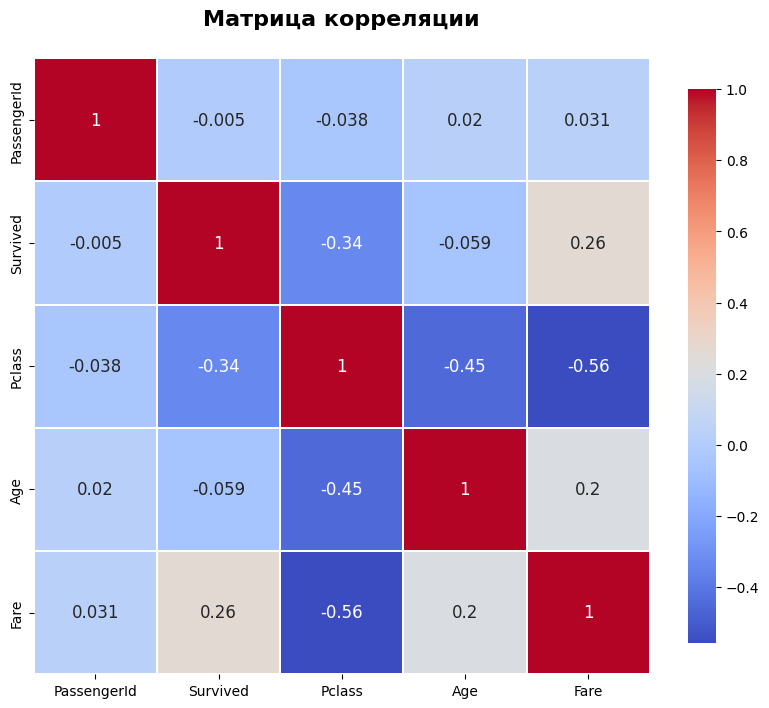

In [18]:
corr=['Pclass', 'Embarked','Sex','Title','Family_size']

plt.figure(figsize=(10, 8))
plt.title('Матрица корреляции', fontsize=16, fontweight='bold', y=1.04)

sns.heatmap(
        df.corr(numeric_only=True), 
        cmap = 'coolwarm',
        square=True, 
        cbar_kws={'shrink':.9 },
        annot=True, 
        linewidths=0.1,vmax=1.0, linecolor='white',
        annot_kws={'fontsize':12 }
    );

Нечисловые, такие как: `Embarked`, `Sex`, `Title`, `Family_size` – посчитаем отдельно

In [19]:
for i in corr:
    print('Survival Correlation by:', i)
    df2=df.groupby(i)['Survived'].mean().reset_index()
    print(df2)
    print('-'*10, '\n')

Survival Correlation by: Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
---------- 

Survival Correlation by: Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009
---------- 

Survival Correlation by: Sex
      Sex  Survived
0  female  0.742038
1    male  0.188908
---------- 

Survival Correlation by: Title
    Title  Survived
0  Master  0.575000
1    Miss  0.702703
2      Mr  0.156673
3     Mrs  0.793651
4    Rare  0.347826
---------- 

Survival Correlation by: Family_size
  Family_size  Survived
0       Alone  0.303538
1       Large  0.161290
2       Small  0.578767
---------- 



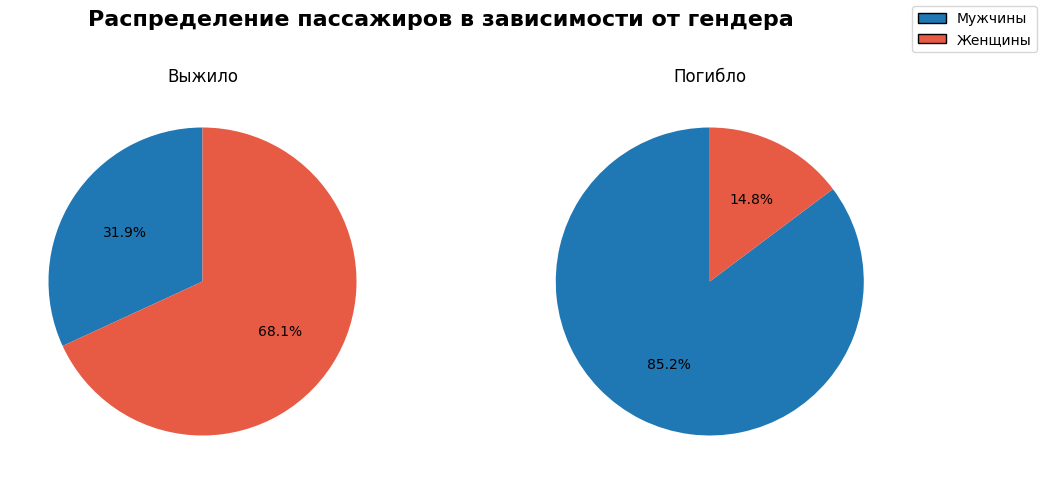

In [20]:
sex_counts = pd.crosstab(train_data["Sex"],  train_data["Survived"])

dead_male = sex_counts.loc[ "male", 0]
dead_female = sex_counts.loc["female", 0]
surv_male = sex_counts.loc["male", 1]
surv_female = sex_counts.loc["female", 1]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Распределение пассажиров в зависимости от гендера', fontsize=16, fontweight='bold', y=1.04)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=Color_1, edgecolor='black', label='Мужчины'),
    Patch(facecolor=Color_2, edgecolor='black', label='Женщины')
    ]
fig.legend(handles=legend_elements, loc="upper right")

ax[0].pie([surv_male, surv_female], labels=None, autopct='%1.1f%%', startangle=90, colors = [Color_1, Color_2]);
ax[1].pie([dead_male, dead_female], labels=None, autopct='%1.1f%%', startangle=90, colors = [Color_1, Color_2]);

ax[0].set_title('Выжило');
ax[1].set_title('Погибло');

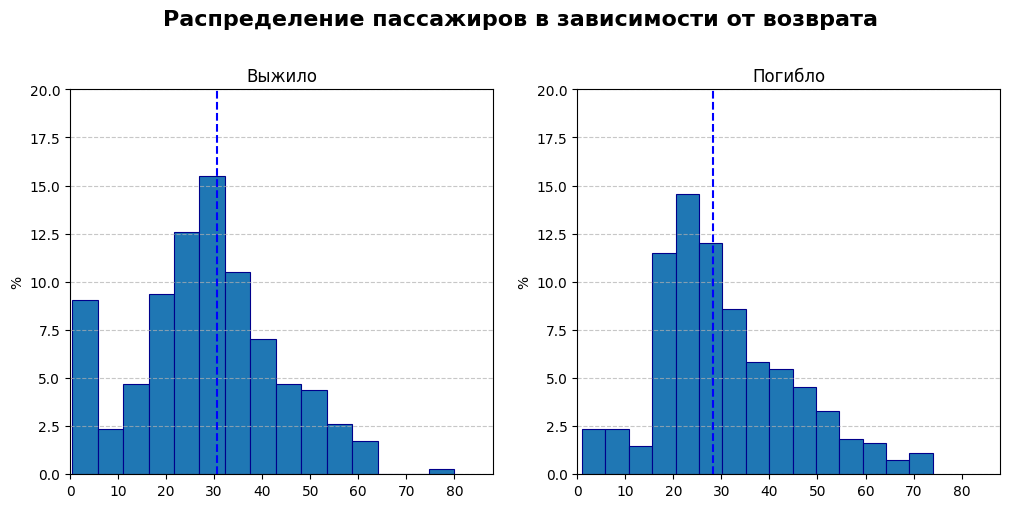

In [21]:
dead_age = train_data[train_data.Survived == 1]['Age']
surv_age = train_data[train_data.Survived == 0]['Age']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Распределение пассажиров в зависимости от возврата', fontsize=16, fontweight='bold', y=1.04)

ax[0].hist(dead_age, bins=15, edgecolor=Color_endge, linewidth=0.8, weights=np.ones_like(dead_age)/len(dead_age)*100) 
ax[1].hist(surv_age, bins=15, edgecolor=Color_endge, linewidth=0.8, weights=np.ones_like(surv_age)/len(surv_age)*100)

ax[0].set_title('Выжило')
ax[1].set_title('Погибло')

mean_surv = np.mean(surv_age)
ax[0].axvline(mean_surv, color='blue', linestyle='--', label='Среднее')

mean_dead = np.mean(dead_age)
ax[1].axvline(mean_dead, color='blue', linestyle='--', label='Среднее')    

xmax = max(dead_age.max(), surv_age.max())

for a in ax: 
    a.set_ylabel('%') 
    a.set_ylim(0, 20) 
    a.set_xlim(0, xmax * 1.1) 
    a.grid(axis="y", linestyle="--", alpha=0.7)

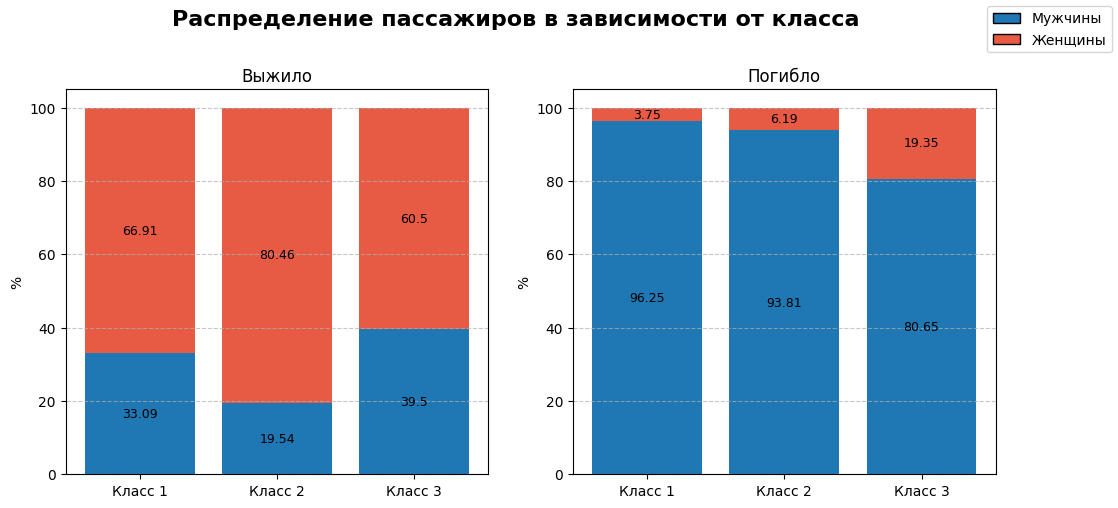

In [22]:
pclass_counts = pd.crosstab([train_data["Pclass"],  train_data["Sex"]],  train_data["Survived"])

cat_par = [f"Класс {i}" for i in range(1,4)]

dead_male = pclass_counts.loc[(slice(None), "male"), 0].values
dead_female = pclass_counts.loc[(slice(None), "female"), 0].values
surv_male = pclass_counts.loc[(slice(None), "male"), 1].values
surv_female = pclass_counts.loc[(slice(None), "female"), 1].values

dead_total = dead_male + dead_female
surv_tatal = surv_male + surv_female

dead_male_abs = dead_male/dead_total * 100
dead_female_abs = dead_female/dead_total * 100
surv_male_abs = surv_male/surv_tatal * 100
surv_female_abs = surv_female/surv_tatal * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Распределение пассажиров в зависимости от класса', fontsize=16, fontweight='bold', y=1.04)

width = 0.8

x = np.arange(len(cat_par))

ax[0].bar(x, surv_male_abs, width = width, label = 'Выжившие мужчины', color = Color_1) #rects1
ax[0].bar(x, surv_female_abs, width = width, bottom = surv_male_abs, label = 'Выжившие женщины', color = Color_2)

ax[1].bar(x, dead_male_abs, width = width, label = 'Погибшие мужчины', color = Color_1) #rects2
ax[1].bar(x, dead_female_abs, width = width, bottom = dead_male_abs, label = 'Погибшие женщины', color = Color_2) 

for i in range(len(x)):
    ax[0].text(i, surv_male_abs[i]/2, round(surv_male_abs[i], 2), ha='center', va='center', fontsize=9)
    ax[0].text(i, surv_male_abs[i] + surv_female_abs[i]/2, round(surv_female_abs[i], 2), ha='center', va='center', fontsize=9)

for i in range(len(x)):
    ax[1].text(i, dead_male_abs[i]/2, round(dead_male_abs[i], 2), ha='center', va='center', fontsize=9)
    ax[1].text(i, dead_male_abs[i] + dead_female_abs[i]/2, round(dead_female_abs[i], 2), ha='center', va='center', fontsize=9)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=Color_1, edgecolor='black', label='Мужчины'),
    Patch(facecolor=Color_2, edgecolor='black', label='Женщины')
    ]
fig.legend(handles=legend_elements, loc="upper right")

ax[0].set_title('Выжило')
ax[1].set_title('Погибло')


for a in ax:
    a.set_ylabel('%')
    a.set_xticks(x)
    a.set_xticklabels(cat_par)
    a.set_ylim(0, 105)
    a.grid(axis="y", linestyle="--", alpha=0.7)



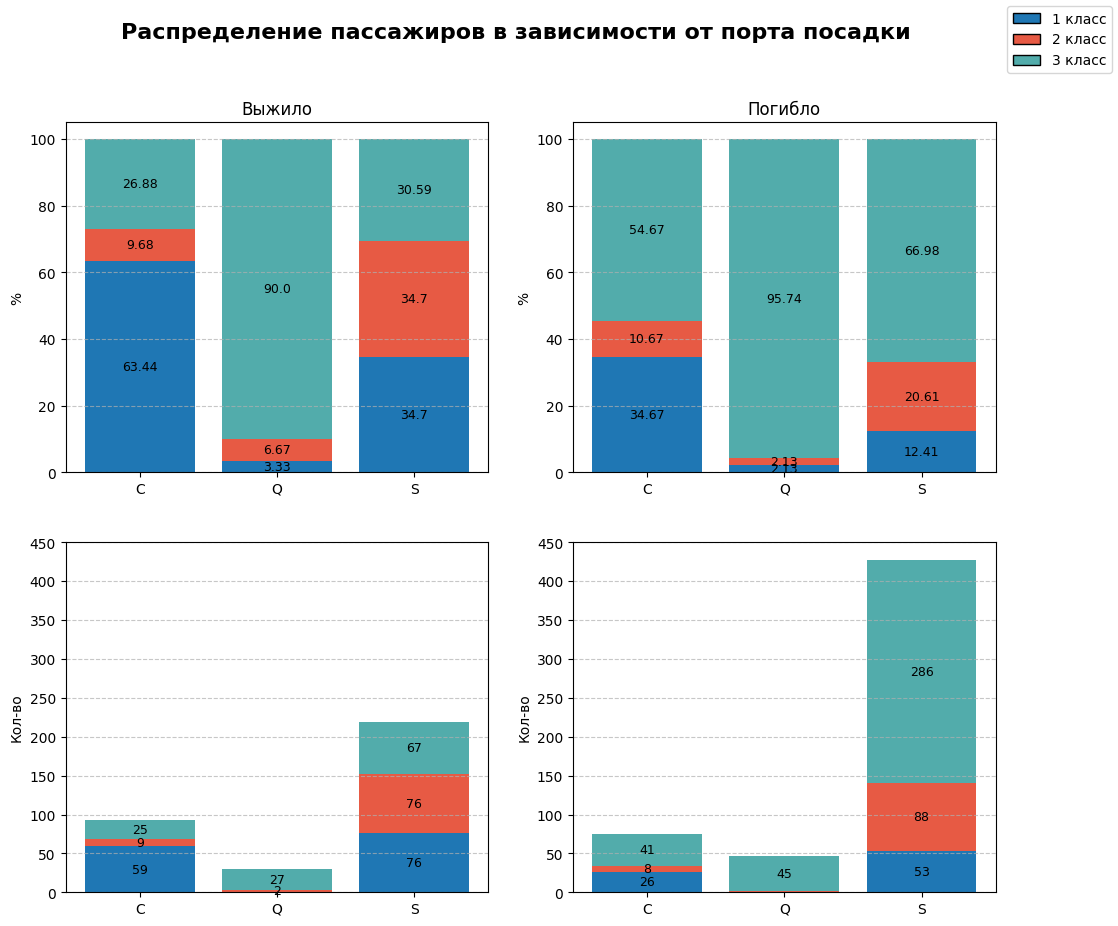

In [23]:
embarked_counts = pd.crosstab([train_data["Embarked"], train_data["Pclass"]],  train_data["Survived"])

dead_С = embarked_counts.loc[(slice(None), 1), 0].values
dead_Q = embarked_counts.loc[(slice(None), 2), 0].values
dead_S = embarked_counts.loc[(slice(None), 3), 0].values
surv_1 = embarked_counts.loc[(slice(None), 1), 1].values
surv_2 = embarked_counts.loc[(slice(None), 2), 1].values
surv_3 = embarked_counts.loc[(slice(None), 3), 1].values

dead_total = dead_С + dead_Q + dead_S
surv_tatal = surv_1 + surv_2 + surv_3

dead_С_abs = dead_С/dead_total * 100
dead_Q_abs = dead_Q/dead_total * 100
dead_S_abs = dead_S/dead_total * 100
surv_1_abs = surv_1/surv_tatal * 100
surv_2_abs = surv_2/surv_tatal * 100
surv_3_abs = surv_3/surv_tatal * 100


cat_par = ['C', 'Q', 'S']

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Распределение пассажиров в зависимости от порта посадки', fontsize=16, fontweight='bold', y=0.98)

width = 0.8

x = np.arange(len(cat_par))

ax[0,0].bar(x, surv_1_abs, width = width, label = 'Выживший 1 класс', color = Color_1) #rects1
ax[0,0].bar(x, surv_2_abs , width = width, bottom = surv_1_abs, label = 'Выживший 2 класс', color = Color_2)
ax[0,0].bar(x, surv_3_abs , width = width, bottom = surv_1_abs+surv_2_abs, label = 'Выживший 3 класс', color = Color_3)

ax[0,1].bar(x, dead_С_abs, width = width, label = 'Погибший 1 класс', color = Color_1) #rects2
ax[0,1].bar(x, dead_Q_abs, width = width, bottom = dead_С_abs, label = 'Погибший 2 класс', color = Color_2)
ax[0,1].bar(x, dead_S_abs , width = width, bottom = dead_С_abs+dead_Q_abs, label = 'Выживший 3 класс', color = Color_3) 

ax[1,0].bar(x, surv_1, width = width, label = 'Выживший 1 класс', color = Color_1) #rects1
ax[1,0].bar(x, surv_2 , width = width, bottom = surv_1, label = 'Выживший 2 класс', color = Color_2)
ax[1,0].bar(x, surv_3 , width = width, bottom = surv_1+surv_2, label = 'Выживший 3 класс', color = Color_3)

ax[1,1].bar(x, dead_С, width = width, label = 'Погибший 1 класс', color = Color_1) #rects2
ax[1,1].bar(x, dead_Q, width = width, bottom = dead_С, label = 'Погибший 2 класс', color = Color_2)
ax[1,1].bar(x, dead_S , width = width, bottom = dead_С+dead_Q, label = 'Выживший 3 класс', color = Color_3) 

for i in range(len(x)):
    if surv_1_abs[i] > 1:
        ax[0,0].text(i, surv_1_abs[i]/2, round(surv_1_abs[i], 2), ha='center', va='center', fontsize=9)
    if surv_2_abs[i] > 1:
        ax[0,0].text(i, surv_1_abs[i] + surv_2_abs[i]/2, round(surv_2_abs[i], 2), ha='center', va='center', fontsize=9)
    if surv_3_abs[i] > 1:
        ax[0,0].text(i, surv_1_abs[i] + surv_2_abs[i] + surv_3_abs[i]/2, round(surv_3_abs[i], 2), ha='center', va='center', fontsize=9)

for i in range(len(x)):
    if dead_С_abs[i] > 1:
        ax[0,1].text(i, dead_С_abs[i]/2, round(dead_С_abs[i], 2), ha='center', va='center', fontsize=9)
    if dead_Q_abs[i] > 1:
        ax[0,1].text(i, dead_С_abs[i] + dead_Q_abs[i]/2, round(dead_Q_abs[i], 2), ha='center', va='center', fontsize=9)
    if dead_S_abs[i] > 1:
        ax[0,1].text(i, dead_С_abs[i] + dead_Q_abs[i] + dead_S_abs[i]/2, round(dead_S_abs[i], 2), ha='center', va='center', fontsize=9)

for i in range(len(x)):
    if surv_1[i] > 1:
        ax[1,0].text(i, surv_1[i]/2, round(surv_1[i], 2), ha='center', va='center', fontsize=9)
    if surv_2[i] > 1:
        ax[1,0].text(i, surv_1[i] + surv_2[i]/2, round(surv_2[i], 2), ha='center', va='center', fontsize=9)
    if surv_3[i] > 1:
        ax[1,0].text(i, surv_1[i] + surv_2[i] + surv_3[i]/2, round(surv_3[i], 2), ha='center', va='center', fontsize=9)

for i in range(len(x)):
    if dead_С[i] > 1:
        ax[1,1].text(i, dead_С[i]/2, round(dead_С[i], 2), ha='center', va='center', fontsize=9)
    if dead_Q[i] > 1:
        ax[1,1].text(i, dead_С[i] + dead_Q[i]/2, round(dead_Q[i], 2), ha='center', va='center', fontsize=9)
    if dead_S[i] > 1:
        ax[1,1].text(i, dead_С[i] + dead_Q[i] + dead_S[i]/2, round(dead_S[i], 2), ha='center', va='center', fontsize=9)        

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=Color_1, edgecolor='black', label='1 класс'),
    Patch(facecolor=Color_2, edgecolor='black', label='2 класс'),
    Patch(facecolor=Color_3, edgecolor='black', label='3 класс')
    ]
fig.legend(handles=legend_elements, loc="upper right")

ax[0,0].set_title('Выжило')
ax[0,1].set_title('Погибло')

for i in range(2):
    ax[0,i].set_ylabel('%')
    ax[0,i].set_xticks(x)
    ax[0,i].set_xticklabels(cat_par)
    ax[0,i].set_ylim(0, 105)
    ax[0,i].grid(axis="y", linestyle="--", alpha=0.7)

for i in range(2):
    ax[1,i].set_ylabel('Кол-во')
    ax[1,i].set_xticks(x)
    ax[1,i].set_xticklabels(cat_par)
    ax[1,i].set_ylim(0, 450)
    ax[1,i].grid(axis="y", linestyle="--", alpha=0.7)

__Выводы:__

- `Gender`: у женщин уровень выживаемости значительно выше, чем у мужчин.

- `Pclass` : у пассажиров первого класса более высокий уровень выживаемости, следовательно социально-экономический статус играет большую роль в шансах на выживание.

- `Embarked` : есть коллеляция выживаймости и порта посадки, однако изучив данные можно прийти к выводу, что в первую очередь порт посадки связан с оциально-экономическим статусом и поэтому связан с выживаймостью.

- `Fare` : стоймость проезда напрямую связанна с классом пасажира, что в свою очередь влияло на выживаймость.

- `Age` : у молодых пассажиров (детей) шансы на выживание были выше, у пожилых — ниже. Большинство погибших составили люди среднего возраста, особенно мужчины.

- `Family_size` : путешественники-одиночки и те, у кого небольшая семья (1–3 человека), показали лучшие результаты по выживанию, чем большие семьи.

- `Title` : некоторые титулы, полученные из имен и потенциально указывающие на социальный статус или профессию, имели разную степень сохранения.



# 3. Обучение моделей
## 3.1 Подготовка данных для обучения

In [24]:
train = df.loc[:890]
train = train.drop("PassengerId", axis=1)
train['Survived'] = train['Survived'].astype('int64')
train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Family_size
0,0,3,male,22,7.2500,S,Mr,Small
1,1,1,female,38,71.2833,C,Mrs,Small
2,1,3,female,26,7.9250,S,Miss,Alone
3,1,1,female,35,53.1000,S,Mrs,Small
4,0,3,male,35,8.0500,S,Mr,Alone


In [25]:
test = df.loc[891:]
test = test.drop(["Survived", "PassengerId"], axis=1)
test.head()

,Pclass,Sex,Age,Fare,Embarked,Title,Family_size
891,3,male,34,7.8292,Q,Mr,Alone
892,3,female,47,7.0000,S,Mrs,Small
893,2,male,62,9.6875,Q,Mr,Alone
894,3,male,27,8.6625,S,Mr,Alone
895,3,female,22,12.2875,S,Mrs,Small


In [26]:
X_train = train.drop("Survived", axis=1)
y_train = train["Survived"]

## 3.2 Подготовка конвеера обработки

In [27]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Binarizer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score
from sklearn import ensemble
from sklearn import gaussian_process
from sklearn import linear_model
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import svm
from sklearn import tree
from sklearn import discriminant_analysis
# from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [28]:
num_cat_tranformation=ColumnTransformer([
                                    ('scaling',MinMaxScaler(),[2,3]), # Нормализация числовых признаков
                                    ('onehotencolding1',OneHotEncoder(),[0,1]), # One-Hot кодирование
                                    ('ordinal',OrdinalEncoder(),[5]), # Порядковое кодирование
                                    ('onehotencolding2',OneHotEncoder(),[4,6]) # One-Hot кодирование
                                    ],remainder='passthrough')

In [29]:
bins=ColumnTransformer([
                        ('Kbins',KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile'),[2,3]),
                        ],remainder='passthrough') # Разбивает столбцы на бины

In [30]:
from sklearn import set_config
set_config(display='diagram')

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_train,y_train,test_size=0.2)

In [32]:
def create_pipeline(algo):
    return Pipeline([
        ('num_cat_transformation', num_cat_tranformation),
        ('bins', bins),
        ('classifier', algo)
    ])

## 3.3 Оценка моделей

In [33]:
algorithms=[
    # Ensemble Methods
    ensemble.AdaBoostClassifier(),
    ensemble.BaggingClassifier(),
    ensemble.ExtraTreesClassifier(),
    ensemble.GradientBoostingClassifier(),
    ensemble.RandomForestClassifier(),

    # Gaussian Processes
    gaussian_process.GaussianProcessClassifier(),
    
    # GLM
    linear_model.LogisticRegressionCV(),
    linear_model.PassiveAggressiveClassifier(),
    linear_model.RidgeClassifierCV(),
    linear_model.SGDClassifier(),
    linear_model.Perceptron(),
    
    # Naive Bayes
    naive_bayes.BernoulliNB(),
    naive_bayes.GaussianNB(),
    
    # Nearest Neighbor
    neighbors.KNeighborsClassifier(),
    
    # SVM
    svm.SVC(probability=True),
    svm.NuSVC(probability=True),
    svm.LinearSVC(),
    
    # Trees    
    tree.DecisionTreeClassifier(),
    tree.ExtraTreeClassifier(),
    
    # Discriminant Analysis
    discriminant_analysis.LinearDiscriminantAnalysis(),
    discriminant_analysis.QuadraticDiscriminantAnalysis(),
    
    # XGBoost
    #XGBClassifier() не работает библиотека
]

In [34]:
model_names = []
CV_Accuracy=[]

for algo in algorithms:
    pipeline = create_pipeline(algo)
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    model_names.append(algo.__class__.__name__)
    CV_Accuracy.append(scores.mean())

In [35]:
model_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': CV_Accuracy})

In [36]:
model_df.sort_values(by='Accuracy', ascending=False, inplace=True)

In [37]:
model_df

,Model,Accuracy
3,GradientBoostingClassifier,0.832818
5,GaussianProcessClassifier,0.830050
15,NuSVC,0.825825
14,SVC,0.821629
1,BaggingClassifier,0.815995
13,KNeighborsClassifier,0.814557
19,LinearDiscriminantAnalysis,0.813169
16,LinearSVC,0.811770
6,LogisticRegressionCV,0.810371
8,RidgeClassifierCV,0.810371
